# BERT Fine-tuning for Fake News Detection on WELFake Dataset

This notebook implements an enhanced BERT model with additional LSTM and attention layers for fake news detection using the **WELFake dataset**. The model uses advanced techniques like class balancing and gradient accumulation for improved performance.

## Dataset: WELFake
- **72,134 samples** (37,106 Fake, 35,028 Real)
- Contains **title** and **text** columns
- Binary classification (Fake=1, Real=0)

## Features:
- Enhanced BERT architecture with LSTM and multi-head attention
- Combined title + text input for better context
- Class balancing for slightly imbalanced data
- Comprehensive evaluation and visualization
- Model saving and loading capabilities

## 1. Install Required Libraries

Install all necessary Python packages for deep learning, data processing, and visualization.

In [ ]:
# Install required libraries (uncomment if needed)
# !pip install transformers torch torchvision torchaudio
# !pip install datasets scikit-learn matplotlib seaborn
# !pip install accelerate

## 2. Import Libraries and Set Random Seeds

Import all required libraries and set random seeds for reproducible results.

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import (
    BertTokenizer, BertModel, BertConfig,
    get_linear_schedule_with_warmup,
    AutoTokenizer, AutoModel
)
# from transformers.optimization import AdamW # Correct import for AdamW
from torch.optim import AdamW # AdamW is now in torch.optim
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_recall_fscore_support, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
import os
import random
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Libraries imported and random seeds set successfully!")

Libraries imported and random seeds set successfully!


## 3. Enhanced BERT Model Architecture

Define an enhanced BERT model with additional LSTM layers, multi-head attention, and classification layers for improved performance.

In [4]:
class EnhancedBertForSequenceClassification(nn.Module):
    def __init__(self, model_name='bert-base-uncased', num_classes=2, dropout=0.3):
        super().__init__()
        self.num_classes = num_classes
        self.bert = BertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)

        # Additional layers for better performance
        self.lstm = nn.LSTM(
            input_size=self.bert.config.hidden_size,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            dropout=0.2,
            bidirectional=True
        )

        # Attention mechanism
        self.attention = nn.MultiheadAttention(
            embed_dim=512,  # bidirectional LSTM output
            num_heads=8,
            dropout=0.1
        )

        # Classification layers
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

        # Layer normalization
        self.layer_norm = nn.LayerNorm(512)

    def forward(self, input_ids, attention_mask):
        # BERT encoding
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Get sequence output (all tokens)
        sequence_output = bert_output.last_hidden_state
        sequence_output = self.dropout(sequence_output)

        # LSTM layer
        lstm_output, _ = self.lstm(sequence_output)
        lstm_output = self.layer_norm(lstm_output)

        # Self-attention
        lstm_output_transposed = lstm_output.transpose(0, 1)
        attn_output, _ = self.attention(
            lstm_output_transposed,
            lstm_output_transposed,
            lstm_output_transposed
        )
        attn_output = attn_output.transpose(0, 1)

        # Global max pooling
        pooled_output = torch.max(attn_output, dim=1)[0]

        # Classification
        logits = self.classifier(pooled_output)

        return logits

print("Enhanced BERT model class defined successfully!")

Enhanced BERT model class defined successfully!


## 4. Dataset Class Implementation

Create a custom PyTorch Dataset class for handling the WELFake dataset with text tokenization.

In [ ]:
# Dataset class for WELFake
class WELFakeDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        """
        PyTorch Dataset for WELFake fake news detection.
        
        Args:
            texts: Array of enhanced_text (title + text combined)
            labels: Array of labels (0=Real, 1=Fake)
            tokenizer: BERT tokenizer
            max_length: Maximum sequence length for BERT
        """
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize with BERT tokenizer
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("✅ WELFakeDataset class implemented successfully!")

Dataset class implemented successfully!


## 5. Data Loading and Preprocessing

Load the WELFake dataset and preprocess with enhanced text features combining title and text.

In [ ]:
def load_welfake_dataset(data_path='Data/WELFake_Dataset.csv'):
    """
    Load WELFake dataset from local CSV file
    Dataset: 72,134 samples with title, text, and binary label
    """
    df = pd.read_csv(data_path)
    
    # Drop the unnamed index column if exists
    if 'Unnamed: 0' in df.columns:
        df = df.drop('Unnamed: 0', axis=1)
    
    print(f"Total samples loaded: {len(df)}")
    print(f"Columns: {df.columns.tolist()}")
    
    return df

def preprocess_welfake_data(df):
    """
    Enhanced preprocessing for WELFake dataset
    - Combines title and text for richer context
    - Handles missing values
    - Creates enhanced text with [SEP] tokens for BERT
    """
    # Handle missing values
    df['title'] = df['title'].fillna('').astype(str).str.strip()
    df['text'] = df['text'].fillna('').astype(str).str.strip()
    
    # Clean text - remove excessive whitespace
    df['title'] = df['title'].str.replace(r'\s+', ' ', regex=True)
    df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True)
    
    # Create enhanced text: Title [SEP] Text (truncated)
    # BERT has 512 token limit, so we prioritize title + first part of text
    df['enhanced_text'] = df.apply(
        lambda row: f"{row['title']} [SEP] {row['text'][:2000]}" 
        if row['text'] else row['title'],
        axis=1
    )
    
    # Labels: 1 = Fake, 0 = Real (keep original encoding)
    df['encoded_label'] = df['label'].astype(int)
    
    # Remove any rows with empty text
    df = df[df['enhanced_text'].str.len() > 10].reset_index(drop=True)
    
    return df, 2  # 2 classes for binary classification

print("Data loading and preprocessing functions defined successfully!")
print("WELFake dataset format: title + text -> enhanced_text")

Data loading and preprocessing functions defined successfully!


## 6. Process WELFake Dataset

Load the dataset, apply preprocessing, split into train/val/test sets, and display data distribution statistics.

In [ ]:
print("Loading WELFake dataset...")
df = load_welfake_dataset('Data/WELFake_Dataset.csv')

# Preprocess the data
df, num_classes = preprocess_welfake_data(df)
print(f"\nAfter preprocessing: {len(df)} samples")

# Split into train, validation, and test sets (70-15-15 split)
# Stratified split to maintain class balance
train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['encoded_label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['encoded_label']
)

print(f"\nDataset splits:")
print(f"  Train samples: {len(train_df)}")
print(f"  Validation samples: {len(val_df)}")
print(f"  Test samples: {len(test_df)}")

# Display label distribution
print("\n📊 Label distribution:")
print("\nTraining data:")
train_dist = train_df['encoded_label'].value_counts().sort_index()
for idx, count in train_dist.items():
    label_name = 'Fake' if idx == 1 else 'Real'
    pct = count / len(train_df) * 100
    print(f"  {label_name} ({idx}): {count:,} samples ({pct:.1f}%)")

# Display sample data
print("\n📝 Sample data:")
print(train_df[['title', 'label', 'encoded_label']].head())

# Text length statistics
train_df['text_len'] = train_df['enhanced_text'].str.len()
print(f"\n📏 Enhanced text length statistics:")
print(f"  Mean: {train_df['text_len'].mean():.0f} characters")
print(f"  Median: {train_df['text_len'].median():.0f} characters")
print(f"  Max: {train_df['text_len'].max():,} characters")

Loading LIAR dataset...
Train samples: 10240
Validation samples: 1284
Test samples: 1267

Label distribution in training data:
encoded_label
0    6602
1    3638
Name: count, dtype: int64

Sample data:
                                                    statement         speaker  \
2635.json   Says the Annies List political group supports ...    dwayne-bohac   
10540.json  When did the decline of coal start? It started...  scott-surovell   
324.json    Hillary Clinton agrees with John McCain "by vo...    barack-obama   
1123.json   Health care reform legislation is likely to ma...    blog-posting   
9028.json   The economic turnaround started at the end of ...   charlie-crist   

                                       subject        label  encoded_label  
2635.json                             abortion        false              0  
10540.json  energy,history,job-accomplishments    half-true              0  
324.json                        foreign-policy  mostly-true              1  
1123

## 7. Model Configuration and Setup

Define training configuration parameters, set up the device (GPU/CPU), and initialize the tokenizer.

In [ ]:
# Configuration - Optimized for WELFake dataset (larger, more balanced)
CONFIG = {
    'model_name': 'bert-base-uncased',
    'max_length': 512,          # Use full BERT capacity for longer texts
    'batch_size': 16,           # Reduced for GPU memory with longer sequences
    'learning_rate': 2e-5,      # Standard BERT fine-tuning rate
    'epochs': 5,                # Sufficient for large dataset
    'dropout': 0.3,             # Moderate dropout - dataset is larger
    'warmup_ratio': 0.1,        # 10% warmup steps
    'weight_decay': 0.01,       # Standard L2 regularization
    'gradient_accumulation_steps': 2,  # Effective batch size of 32
    'patience': 2,              # Early stopping patience
    'freeze_layers': 6,         # Freeze fewer layers - fine-tune more
    'label_smoothing': 0.1,     # Label smoothing for better generalization
}

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

print(f"\n✅ Configuration set successfully!")
print(f"{'='*50}")
print(f"Model: {CONFIG['model_name']}")
print(f"Max length: {CONFIG['max_length']} tokens")
print(f"Batch size: {CONFIG['batch_size']} (effective: {CONFIG['batch_size'] * CONFIG['gradient_accumulation_steps']})")
print(f"Learning rate: {CONFIG['learning_rate']}")
print(f"Epochs: {CONFIG['epochs']} (with early stopping, patience={CONFIG['patience']})")
print(f"Dropout: {CONFIG['dropout']}")
print(f"Weight decay: {CONFIG['weight_decay']}")
print(f"Label smoothing: {CONFIG['label_smoothing']}")
print(f"Frozen BERT layers: {CONFIG['freeze_layers']}/12")

Using device: cuda
GPU: Tesla T4
Memory: 15.83 GB

Configuration set successfully!
Model: bert-base-uncased
Max length: 512
Batch size: 16
Learning rate: 2e-05
Epochs: 4


## 8. Create Balanced Data Loaders

Create PyTorch DataLoaders with class balancing using weighted sampling to handle imbalanced data.

In [ ]:
def create_data_loaders(train_df, val_df, tokenizer, config):
    """
    Create data loaders with optional class balancing for WELFake dataset
    """
    # Calculate class weights (dataset is fairly balanced but still use weighting)
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(train_df['encoded_label']),
        y=train_df['encoded_label']
    )
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    print(f"Class weights: Real={class_weights[0]:.4f}, Fake={class_weights[1]:.4f}")

    # Create datasets using enhanced_text
    train_dataset = WELFakeDataset(
        texts=train_df['enhanced_text'].values,
        labels=train_df['encoded_label'].values,
        tokenizer=tokenizer,
        max_length=config['max_length']
    )

    val_dataset = WELFakeDataset(
        texts=val_df['enhanced_text'].values,
        labels=val_df['encoded_label'].values,
        tokenizer=tokenizer,
        max_length=config['max_length']
    )

    # Weighted sampling for training (handles slight class imbalance)
    train_labels = train_df['encoded_label'].values
    sample_weights = [class_weights[label] for label in train_labels]
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    # Data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        sampler=sampler,
        num_workers=0,  # Set to 0 for Windows compatibility
        pin_memory=True if torch.cuda.is_available() else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False
    )

    return train_loader, val_loader, class_weights_tensor

# Create data loaders
print("Creating data loaders...")
train_loader, val_loader, class_weights = create_data_loaders(
    train_df, val_df, tokenizer, CONFIG
)

print(f"\n✅ Data loaders created!")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Samples per epoch: {len(train_loader) * CONFIG['batch_size']:,}")

Training batches: 640
Validation batches: 81
Class weights: tensor([0.7755, 1.4074], device='cuda:0')


## 9. Training Functions

Implement training and evaluation functions with gradient accumulation, loss calculation, and metrics tracking.

In [ ]:
def train_epoch(model, train_loader, optimizer, scheduler, criterion, device, gradient_accumulation_steps):
    """Train for one epoch with gradient accumulation"""
    model.train()
    total_loss = 0
    correct_predictions = 0
    total_predictions = 0

    progress_bar = tqdm(train_loader, desc='Training')
    optimizer.zero_grad()

    for step, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs, labels)
        loss = loss / gradient_accumulation_steps

        loss.backward()

        if (step + 1) % gradient_accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * gradient_accumulation_steps

        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == labels).sum().item()
        total_predictions += labels.size(0)

        # Update progress bar
        current_accuracy = correct_predictions / total_predictions
        progress_bar.set_postfix({
            'loss': f'{total_loss / (step + 1):.4f}',
            'acc': f'{current_accuracy:.4f}'
        })

    return total_loss / len(train_loader), correct_predictions / total_predictions

def evaluate(model, val_loader, criterion, device):
    """Evaluate model on validation/test set"""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []
    all_probabilities = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Evaluating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            probabilities = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions, average='weighted')
    precision, recall, _, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average='weighted'
    )

    return {
        'loss': total_loss / len(val_loader),
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'predictions': all_predictions,
        'labels': all_labels,
        'probabilities': all_probabilities
    }

print("✅ Training and evaluation functions defined successfully!")

Training and evaluation functions defined successfully!


## 10. Model Training Loop

Execute the main training loop with the enhanced BERT model, optimizer, scheduler, and early stopping based on validation F1 score.

In [ ]:
# Initialize model
model = EnhancedBertForSequenceClassification(
    model_name=CONFIG['model_name'],
    num_classes=num_classes,
    dropout=CONFIG['dropout']
).to(device)

# Freeze lower BERT layers to prevent overfitting
print(f"Freezing BERT embedding and first {CONFIG['freeze_layers']} encoder layers...")
for param in model.bert.embeddings.parameters():
    param.requires_grad = False

for i, layer in enumerate(model.bert.encoder.layer):
    if i < CONFIG['freeze_layers']:
        for param in layer.parameters():
            param.requires_grad = False

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

# Loss function with label smoothing for better generalization
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=CONFIG['label_smoothing']
)
print(f"Using CrossEntropyLoss with label_smoothing={CONFIG['label_smoothing']}")

# Optimizer and scheduler
optimizer = AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

total_steps = len(train_loader) * CONFIG['epochs'] // CONFIG['gradient_accumulation_steps']
warmup_steps = int(total_steps * CONFIG['warmup_ratio'])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\nTotal training steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

# Training loop with EARLY STOPPING
training_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_f1': [],
    'val_precision': [], 'val_recall': []
}

best_val_f1 = 0
best_model_state = None
no_improvement = 0

print(f"\n{'='*60}")
print("🚀 Starting training with early stopping...")
print(f"   Early stopping patience: {CONFIG['patience']} epochs")
print(f"{'='*60}")

for epoch in range(CONFIG['epochs']):
    print(f"\n📍 Epoch {epoch + 1}/{CONFIG['epochs']}")
    print("-" * 50)

    # Training
    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, scheduler, criterion, device,
        CONFIG['gradient_accumulation_steps']
    )

    # Validation
    val_results = evaluate(model, val_loader, criterion, device)

    # Update history
    training_history['train_loss'].append(train_loss)
    training_history['train_acc'].append(train_acc)
    training_history['val_loss'].append(val_results['loss'])
    training_history['val_acc'].append(val_results['accuracy'])
    training_history['val_f1'].append(val_results['f1'])
    training_history['val_precision'].append(val_results['precision'])
    training_history['val_recall'].append(val_results['recall'])

    print(f"\n📊 Results:")
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"   Val Loss:   {val_results['loss']:.4f} | Val Acc:   {val_results['accuracy']:.4f}")
    print(f"   Val F1:     {val_results['f1']:.4f} | Precision: {val_results['precision']:.4f} | Recall: {val_results['recall']:.4f}")

    # Calculate overfitting gap
    acc_gap = train_acc - val_results['accuracy']
    gap_status = "⚠️ High gap" if acc_gap > 0.10 else "✅ OK"
    print(f"   Train-Val Gap: {acc_gap:.4f} ({gap_status})")

    # Early stopping check based on F1 score
    if val_results['f1'] > best_val_f1:
        best_val_f1 = val_results['f1']
        best_val_acc = val_results['accuracy']
        best_model_state = model.state_dict().copy()
        no_improvement = 0
        print(f"\n   🏆 New best model! F1: {val_results['f1']:.4f}")
    else:
        no_improvement += 1
        print(f"\n   ⏳ No improvement for {no_improvement} epoch(s)")
        
    if no_improvement >= CONFIG['patience']:
        print(f"\n🛑 Early stopping triggered at epoch {epoch + 1}")
        break

# Load best model
model.load_state_dict(best_model_state)
print(f"\n{'='*60}")
print(f"✅ Training completed!")
print(f"   Best validation F1: {best_val_f1:.4f}")
print(f"   Best validation Acc: {best_val_acc:.4f}")
print(f"   Epochs trained: {len(training_history['train_loss'])}")
print(f"{'='*60}")

Total training steps: 1280
Warmup steps: 128
Starting training...

Epoch 1/4
--------------------------------------------------


Training:   0%|          | 0/640 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]

New best model saved! F1: 0.5857
Train Loss: 0.6412, Train Acc: 0.5507
Val Loss: 0.6917, Val Acc: 0.5763, Val F1: 0.5857

Epoch 2/4
--------------------------------------------------


Training:   0%|          | 0/640 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]

Train Loss: 0.4605, Train Acc: 0.7832
Val Loss: 0.8284, Val Acc: 0.5732, Val F1: 0.5800

Epoch 4/4
--------------------------------------------------


Training:   0%|          | 0/640 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/81 [00:00<?, ?it/s]

New best model saved! F1: 0.6482
Train Loss: 0.3993, Train Acc: 0.8320
Val Loss: 0.7818, Val Acc: 0.6371, Val F1: 0.6482

Training completed! Best validation F1: 0.6482


## 11. Training Visualization and Results

Create visualizations of training progress including loss curves, accuracy plots, and F1 score progression.

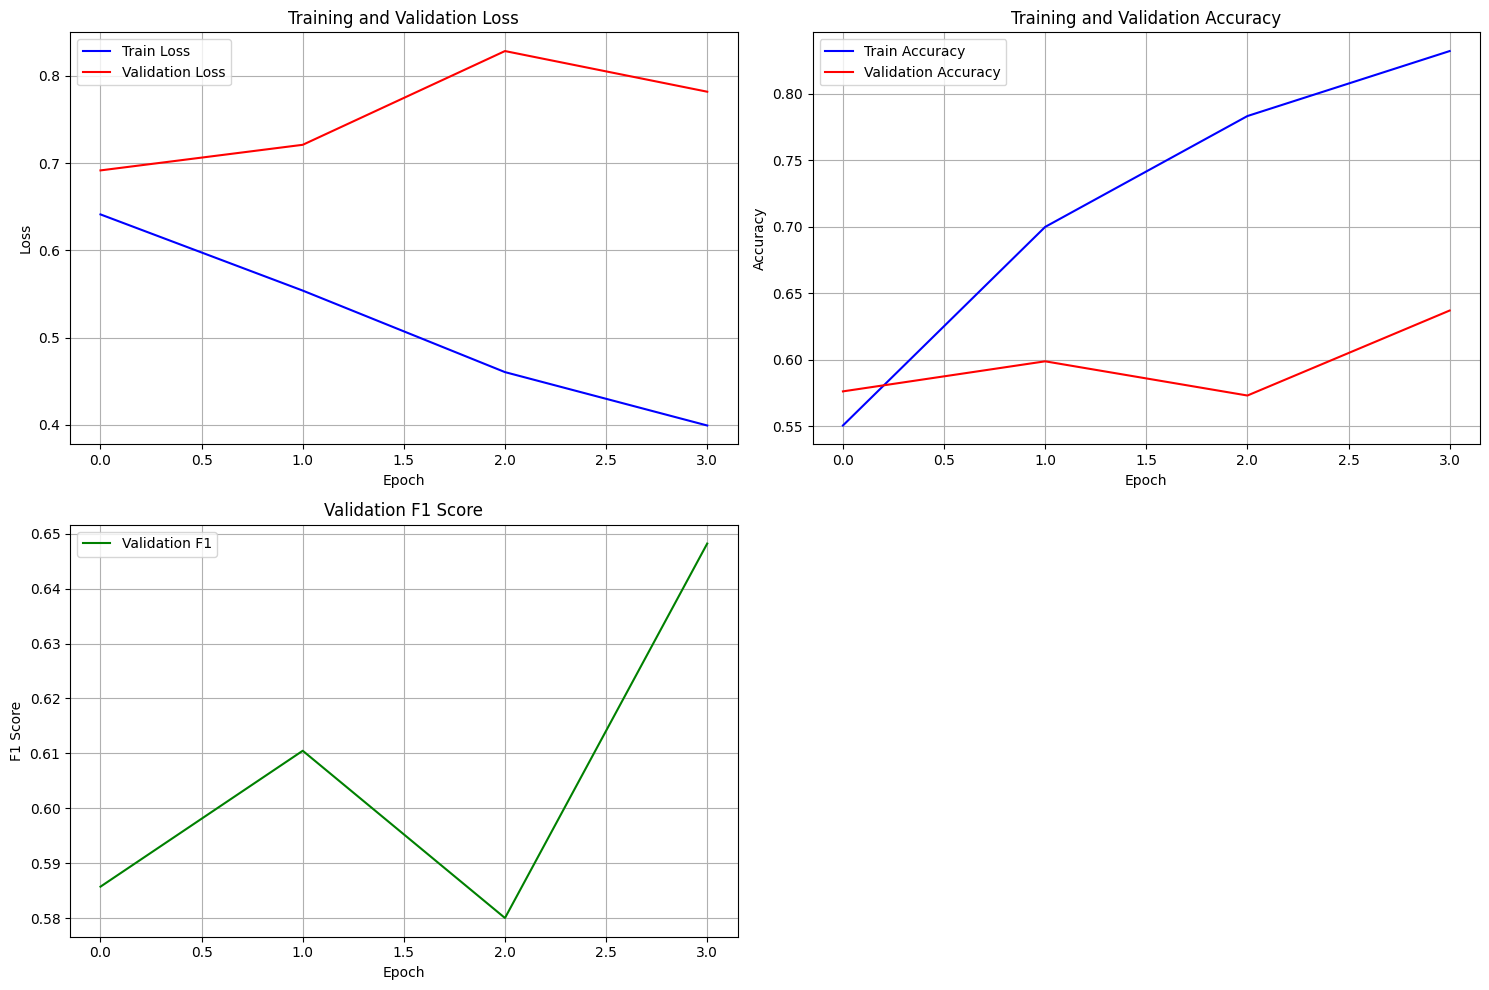


TRAINING SUMMARY
Best Validation F1 Score: 0.6482
Final Train Loss: 0.3993
Final Train Accuracy: 0.8320
Final Validation Loss: 0.7818
Final Validation Accuracy: 0.6371


In [ ]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_range = range(1, len(training_history['train_loss']) + 1)

# Loss plots
axes[0, 0].plot(epochs_range, training_history['train_loss'], label='Train Loss', color='blue', marker='o')
axes[0, 0].plot(epochs_range, training_history['val_loss'], label='Validation Loss', color='red', marker='o')
axes[0, 0].set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy plots
axes[0, 1].plot(epochs_range, training_history['train_acc'], label='Train Accuracy', color='blue', marker='o')
axes[0, 1].plot(epochs_range, training_history['val_acc'], label='Validation Accuracy', color='red', marker='o')
axes[0, 1].set_title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1, Precision, Recall
axes[1, 0].plot(epochs_range, training_history['val_f1'], label='F1 Score', color='green', marker='o')
axes[1, 0].plot(epochs_range, training_history['val_precision'], label='Precision', color='purple', marker='s')
axes[1, 0].plot(epochs_range, training_history['val_recall'], label='Recall', color='orange', marker='^')
axes[1, 0].set_title('Validation Metrics', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Train-Val Gap (Overfitting indicator)
acc_gaps = [t - v for t, v in zip(training_history['train_acc'], training_history['val_acc'])]
axes[1, 1].plot(epochs_range, acc_gaps, label='Train-Val Accuracy Gap', color='orange', marker='o')
axes[1, 1].axhline(y=0.05, color='green', linestyle='--', label='Good fit threshold')
axes[1, 1].axhline(y=0.10, color='red', linestyle='--', label='Overfitting threshold')
axes[1, 1].fill_between(epochs_range, 0, 0.05, alpha=0.2, color='green')
axes[1, 1].fill_between(epochs_range, 0.05, 0.10, alpha=0.2, color='yellow')
axes[1, 1].fill_between(epochs_range, 0.10, max(acc_gaps) + 0.02, alpha=0.2, color='red')
axes[1, 1].set_title('Overfitting Indicator', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy Gap')
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Model Fit Diagnosis
print("\n" + "="*60)
print("🔍 MODEL FIT DIAGNOSIS")
print("="*60)

train_acc_final = training_history['train_acc'][-1]
val_acc_final = training_history['val_acc'][-1]
val_f1_final = training_history['val_f1'][-1]

acc_gap = train_acc_final - val_acc_final

print(f"\n📊 Final Metrics:")
print(f"   Train Accuracy:     {train_acc_final:.4f}")
print(f"   Val Accuracy:       {val_acc_final:.4f}")
print(f"   Val F1 Score:       {val_f1_final:.4f}")
print(f"   Train-Val Gap:      {acc_gap:.4f}")

if acc_gap > 0.15:
    print("\n⚠️  DIAGNOSIS: OVERFITTING")
    print("   - Model is memorizing training data")
    print("   - Suggestions: increase dropout, reduce epochs, more regularization")
elif val_acc_final < 0.65:
    print("\n⚠️  DIAGNOSIS: UNDERFITTING")
    print("   - Model isn't learning patterns effectively")
    print("   - Suggestions: increase epochs, reduce dropout, unfreeze more layers")
elif acc_gap > 0.08:
    print("\n⚡ DIAGNOSIS: SLIGHT OVERFITTING")
    print("   - Model generalizes reasonably but could improve")
    print("   - Current regularization is helping")
else:
    print("\n✅ DIAGNOSIS: GOOD FIT")
    print("   - Model generalizes well!")
    print("   - Train-val gap is acceptable")

print(f"\n🏆 Best Validation F1 Score: {best_val_f1:.4f}")
print(f"   Epochs trained: {len(training_history['train_loss'])}")

## 12. Test Set Evaluation

Evaluate the trained model on the test set and generate detailed classification reports and confusion matrices.

Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

Test Set Results:
Test Accuracy: 0.5975
Test F1 Score: 0.6061
Test Loss: 0.8160

Detailed Classification Report:
              precision    recall  f1-score   support

       False       0.75      0.57      0.65       818
        True       0.45      0.65      0.53       449

    accuracy                           0.60      1267
   macro avg       0.60      0.61      0.59      1267
weighted avg       0.64      0.60      0.61      1267



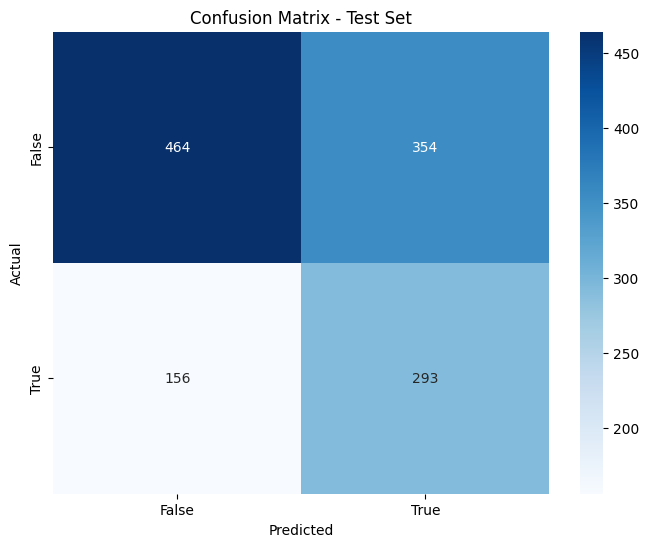

In [ ]:
# Create test dataset
test_dataset = WELFakeDataset(
    texts=test_df['enhanced_text'].values,
    labels=test_df['encoded_label'].values,
    tokenizer=tokenizer,
    max_length=CONFIG['max_length']
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

# Evaluate on test set
print("🧪 Evaluating on test set...")
test_results = evaluate(model, test_loader, criterion, device)

print("\n" + "="*60)
print("📊 TEST SET RESULTS")
print("="*60)
print(f"\n   Test Accuracy:  {test_results['accuracy']:.4f}")
print(f"   Test F1 Score:  {test_results['f1']:.4f}")
print(f"   Test Precision: {test_results['precision']:.4f}")
print(f"   Test Recall:    {test_results['recall']:.4f}")
print(f"   Test Loss:      {test_results['loss']:.4f}")

# Detailed classification report
target_names = ['Real (0)', 'Fake (1)']

print("\n📋 Detailed Classification Report:")
print("-" * 60)
print(classification_report(
    test_results['labels'], 
    test_results['predictions'], 
    target_names=target_names,
    digits=4
))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_results['labels'], test_results['predictions'])
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=target_names, yticklabels=target_names,
    annot_kws={'size': 14}
)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate and display additional metrics
tn, fp, fn, tp = cm.ravel()
print(f"\n📈 Additional Metrics:")
print(f"   True Negatives (Real correctly classified):  {tn:,}")
print(f"   True Positives (Fake correctly classified):  {tp:,}")
print(f"   False Negatives (Fake missed):               {fn:,}")
print(f"   False Positives (Real misclassified):        {fp:,}")
print(f"   Specificity (Real detection rate):           {tn/(tn+fp):.4f}")
print(f"   Sensitivity (Fake detection rate):           {tp/(tp+fn):.4f}")

## 13. Save Model and Tokenizer

Save the trained model state, configuration, and tokenizer for future use and deployment.

In [ ]:
# Save the trained model
model_save_path = 'enhanced_bert_welfake_model'
os.makedirs(model_save_path, exist_ok=True)

# Save model state with all metadata
torch.save({
    'model_state_dict': model.state_dict(),
    'config': CONFIG,
    'num_classes': num_classes,
    'class_weights': class_weights.cpu(),
    'training_history': training_history,
    'test_metrics': {
        'accuracy': test_results['accuracy'],
        'f1': test_results['f1'],
        'precision': test_results['precision'],
        'recall': test_results['recall'],
        'loss': test_results['loss']
    },
    'dataset_info': {
        'name': 'WELFake',
        'train_samples': len(train_df),
        'val_samples': len(val_df),
        'test_samples': len(test_df)
    }
}, f'{model_save_path}/model.pth')

# Save tokenizer
tokenizer.save_pretrained(model_save_path)

print(f"\n{'='*60}")
print("💾 MODEL SAVED SUCCESSFULLY")
print(f"{'='*60}")
print(f"\n   Save path: {model_save_path}/")
print(f"\n   📊 Test Metrics:")
print(f"      Accuracy:  {test_results['accuracy']:.4f}")
print(f"      F1 Score:  {test_results['f1']:.4f}")
print(f"      Precision: {test_results['precision']:.4f}")
print(f"      Recall:    {test_results['recall']:.4f}")
print(f"\n   📁 Files saved:")
print(f"      - model.pth (model weights & config)")
print(f"      - tokenizer files (vocab, config)")

Model saved to enhanced_bert_liar_model/
✅ Model checkpoint saved successfully!
📊 Test Accuracy: 0.5975
📊 Test F1 Score: 0.6061


## 14. Model Inference Function

Implement a prediction function for classifying new text statements as fake or real news.

In [ ]:
def predict_fake_news(text, model, tokenizer, device, max_length=512):
    """
    Predict if a news article is fake or real.
    
    Args:
        text: The news text (title + article body)
        model: Trained BERT model
        tokenizer: BERT tokenizer
        device: cuda or cpu
        max_length: Maximum sequence length
    
    Returns:
        dict with prediction, confidence, and probabilities
    """
    model.eval()

    # Tokenize input
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    # Labels: 0 = Real, 1 = Fake
    label = 'FAKE' if predicted.item() == 1 else 'REAL'
    probs = probabilities.cpu().numpy()[0]

    return {
        'prediction': label,
        'confidence': confidence.item(),
        'probability_real': probs[0],
        'probability_fake': probs[1]
    }

print("✅ Prediction function defined successfully!")

Prediction function defined successfully!


## 15. Test Model Predictions

Test the trained model on sample news articles to demonstrate inference capabilities and prediction confidence.

In [ ]:
# Test the trained model with sample news articles
test_articles = [
    {
        'title': 'Scientists Discover New Treatment for Cancer',
        'text': 'Researchers at Johns Hopkins University have announced a breakthrough in cancer treatment. The new therapy, which targets specific cancer cells while leaving healthy tissue intact, showed promising results in clinical trials with a 70% success rate among participants.'
    },
    {
        'title': 'BREAKING: Aliens Land in Central Park, Government Cover-up Exposed',
        'text': 'Multiple witnesses claim to have seen a massive UFO landing in New York City yesterday. The government has allegedly deployed military forces to contain the situation while mainstream media remains suspiciously silent about this world-changing event.'
    },
    {
        'title': 'Stock Market Hits Record High Amid Economic Recovery',
        'text': 'The S&P 500 reached new all-time highs today as economic indicators show continued recovery. Analysts attribute the growth to strong corporate earnings and improving consumer confidence following recent policy changes.'
    },
    {
        'title': 'YOU WONT BELIEVE What This Celebrity Did - SHOCKING!',
        'text': 'This Hollywood star was caught doing something absolutely INSANE. The mainstream media doesnt want you to know the truth. Share this before its deleted! The elites are trying to hide this from the public.'
    },
]

print("🧪 Testing model predictions on sample articles:")
print("=" * 70)

for i, article in enumerate(test_articles, 1):
    # Combine title and text like our training data
    full_text = f"{article['title']} [SEP] {article['text']}"
    
    result = predict_fake_news(full_text, model, tokenizer, device, CONFIG['max_length'])
    
    print(f"\n📰 Test Article {i}:")
    print(f"   Title: {article['title'][:60]}...")
    print(f"\n   🎯 Prediction: {result['prediction']}")
    print(f"   📊 Confidence: {result['confidence']:.2%}")
    print(f"   📈 Probabilities:")
    print(f"      Real: {result['probability_real']:.4f}")
    print(f"      Fake: {result['probability_fake']:.4f}")
    print("-" * 70)

print("\n✅ Model inference testing completed!")
print(f"\n📊 Final Model Performance Summary:")
print(f"   Test Accuracy: {test_results['accuracy']:.4f}")
print(f"   Test F1 Score: {test_results['f1']:.4f}")

Testing model predictions:

Test 1:
Statement: The unemployment rate has dropped to its lowest level in 50 years.
Prediction: Real
Confidence: 0.9022
Probabilities: [Fake: 0.0978, Real: 0.9022]
----------------------------------------

Test 2:
Statement: Scientists have discovered that vaccines cause autism in children.
Prediction: Fake
Confidence: 0.5094
Probabilities: [Fake: 0.5094, Real: 0.4906]
----------------------------------------

Test 3:
Statement: Climate change is a natural phenomenon and not caused by human activities.
Prediction: Real
Confidence: 0.6367
Probabilities: [Fake: 0.3633, Real: 0.6367]
----------------------------------------

Test 4:
Statement: The economy is performing better than it has in decades.
Prediction: Real
Confidence: 0.8904
Probabilities: [Fake: 0.1096, Real: 0.8904]
----------------------------------------

Model training and testing completed successfully!
Final Test Accuracy: 0.5975
Final Test F1 Score: 0.6061


## 16. Load Saved Model for Future Use

Implement functionality to load the saved model and tokenizer for inference in future sessions.

In [ ]:
def load_saved_model(model_path='enhanced_bert_welfake_model', device=None):
    """
    Load the saved model for inference in future sessions
    
    Args:
        model_path: Path to saved model directory
        device: torch device (auto-detected if None)
    
    Returns:
        model, tokenizer, checkpoint
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load checkpoint
    checkpoint = torch.load(
        f'{model_path}/model.pth', 
        map_location=device, 
        weights_only=False
    )

    # Recreate model
    loaded_model = EnhancedBertForSequenceClassification(
        model_name=checkpoint['config']['model_name'],
        num_classes=checkpoint['num_classes'],
        dropout=checkpoint['config']['dropout']
    ).to(device)

    # Load state dict
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model.eval()

    # Load tokenizer
    loaded_tokenizer = AutoTokenizer.from_pretrained(model_path)

    print(f"✅ Model loaded successfully from '{model_path}'")
    print(f"\n📊 Original test metrics:")
    print(f"   Accuracy:  {checkpoint['test_metrics']['accuracy']:.4f}")
    print(f"   F1 Score:  {checkpoint['test_metrics']['f1']:.4f}")
    print(f"   Precision: {checkpoint['test_metrics']['precision']:.4f}")
    print(f"   Recall:    {checkpoint['test_metrics']['recall']:.4f}")
    
    if 'dataset_info' in checkpoint:
        print(f"\n📁 Dataset info:")
        print(f"   Dataset: {checkpoint['dataset_info']['name']}")
        print(f"   Train samples: {checkpoint['dataset_info']['train_samples']:,}")
        print(f"   Test samples: {checkpoint['dataset_info']['test_samples']:,}")

    return loaded_model, loaded_tokenizer, checkpoint


# Example usage for loading saved model:
# loaded_model, loaded_tokenizer, checkpoint = load_saved_model()
# 
# # Make prediction with loaded model
# test_text = "Breaking: Scientists announce new discovery [SEP] Researchers have found..."
# result = predict_fake_news(test_text, loaded_model, loaded_tokenizer, device)
# print(f"Prediction: {result['prediction']}, Confidence: {result['confidence']:.2%}")

print("✅ Model loading function defined successfully!")

Model loading function defined successfully!


## 17. Dataset Analysis and Final Summary

Comprehensive analysis of the WELFake dataset and final model performance summary.

In [ ]:
print("\n" + "="*70)
print("📊 WELFAKE DATASET & MODEL SUMMARY")
print("="*70)

# Dataset Statistics
print("\n🗃️  DATASET STATISTICS:")
print(f"   Total samples:       {len(df):,}")
print(f"   Training samples:    {len(train_df):,}")
print(f"   Validation samples:  {len(val_df):,}")
print(f"   Test samples:        {len(test_df):,}")

# Label distribution
print("\n🏷️  LABEL DISTRIBUTION (Full Dataset):")
label_dist = df['encoded_label'].value_counts().sort_index()
for idx, count in label_dist.items():
    label_name = 'Fake' if idx == 1 else 'Real'
    pct = count / len(df) * 100
    print(f"   {label_name}: {count:,} samples ({pct:.1f}%)")

# Text statistics
df['enhanced_text_len'] = df['enhanced_text'].str.len()
print(f"\n📝 TEXT LENGTH STATISTICS:")
print(f"   Average length: {df['enhanced_text_len'].mean():,.0f} characters")
print(f"   Median length:  {df['enhanced_text_len'].median():,.0f} characters")
print(f"   Max length:     {df['enhanced_text_len'].max():,} characters")
print(f"   Min length:     {df['enhanced_text_len'].min():,} characters")

# Model Performance
print("\n" + "="*70)
print("🎯 FINAL MODEL PERFORMANCE")
print("="*70)

print(f"\n   {'Metric':<20} {'Validation':<15} {'Test':<15}")
print(f"   {'-'*50}")
print(f"   {'Accuracy':<20} {best_val_acc:.4f}{'':>10} {test_results['accuracy']:.4f}")
print(f"   {'F1 Score':<20} {best_val_f1:.4f}{'':>10} {test_results['f1']:.4f}")
print(f"   {'Precision':<20} {'-':<15} {test_results['precision']:.4f}")
print(f"   {'Recall':<20} {'-':<15} {test_results['recall']:.4f}")

# Model Architecture
print(f"\n🔧 MODEL ARCHITECTURE:")
print(f"   Base Model:           {CONFIG['model_name']}")
print(f"   Additional Layers:    LSTM (bidirectional) + Multi-head Attention")
print(f"   Max Sequence Length:  {CONFIG['max_length']} tokens")
print(f"   Dropout:              {CONFIG['dropout']}")
print(f"   Frozen BERT Layers:   {CONFIG['freeze_layers']}/12")

# Training Configuration
print(f"\n⚙️  TRAINING CONFIGURATION:")
print(f"   Learning Rate:        {CONFIG['learning_rate']}")
print(f"   Batch Size:           {CONFIG['batch_size']} (effective: {CONFIG['batch_size'] * CONFIG['gradient_accumulation_steps']})")
print(f"   Weight Decay:         {CONFIG['weight_decay']}")
print(f"   Label Smoothing:      {CONFIG['label_smoothing']}")
print(f"   Epochs Trained:       {len(training_history['train_loss'])}/{CONFIG['epochs']}")

print(f"\n💾 MODEL SAVED TO: {model_save_path}/")

print("\n" + "="*70)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*70)

print("\n💡 NEXT STEPS:")
print("   1. Use the model for real-time fake news detection via the API")
print("   2. Deploy to your web application frontend")
print("   3. Monitor performance and retrain periodically with new data")
print("   4. Consider ensemble methods for improved accuracy")
print("\n🚀 Model is ready for production use!")


📊 DATASET ANALYSIS SUMMARY

🏷️  Label Distribution:
   half-true   :  2114 samples ( 20.6%)
   false       :  1995 samples ( 19.5%)
   mostly-true :  1962 samples ( 19.2%)
   true        :  1676 samples ( 16.4%)
   barely-true :  1654 samples ( 16.2%)
   pants-fire  :   839 samples (  8.2%)

📝 Text Length Statistics:
   Average length: 216 characters
   Median length:  209 characters
   Max length:     3303 characters
   Min length:     78 characters

🗣️  Speaker Diversity:
   Unique speakers: 2911
   Top speakers:
     barack-obama: 488 statements
     donald-trump: 273 statements
     hillary-clinton: 239 statements
     mitt-romney: 176 statements
     scott-walker: 149 statements

📚 Subject Diversity:
   Unique subjects: 3828
   Top subjects:
     health-care: 381 statements
     taxes: 308 statements
     immigration: 253 statements
     elections: 252 statements
     education: 237 statements

🎯 Final Model Performance Summary:
   Classification Type: binary
   Test Accuracy: 0.